In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import re

In [4]:
def load_ccil_csv(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    return df

In [5]:
GSEC_PATTERN = re.compile(r'^\d{2}\.\d{2}\s+GOVT\.\s+STOCK\s+(\d{4})', re.IGNORECASE)

def filter_and_extract_maturity(df):
    df = df.copy()
    extracted = df['Security Description'].str.extract(GSEC_PATTERN)
    df['maturity_year'] = pd.to_numeric(extracted[0], errors='coerce')
    df = df[df['maturity_year'].notna()].copy()
    df['maturity_year'] = df['maturity_year'].astype(int)
    return df

In [6]:
def add_dates_and_residual_maturity(df):
    df = df.copy()
    df['trade_date'] = pd.to_datetime(df['Trade'], format='%d-%m-%Y')
    df['residual_maturity'] = df['maturity_year'] - df['trade_date'].dt.year
    # trades of already-matured or clearly bad rows
    df = df[df['residual_maturity'] >= 0]
    return df

In [7]:
BUCKET_TARGETS = {
    '1Y': 1,
    '2Y': 2,
    '5Y': 5,
    '10Y': 10,
    '15Y': 15,
    '30Y': 30,
}

def assign_bucket(residual_years):
    closest = min(BUCKET_TARGETS.items(), key=lambda kv: abs(kv[1] - residual_years))
    return closest[0]

def add_bucket(df):
    df = df.copy()
    df['bucket'] = df['residual_maturity'].apply(assign_bucket)
    return df

In [8]:
MIN_TRADES = 5

def build_daily_panel(df, trade_indicator_filter='NRML', min_trades=MIN_TRADES):
    df = df.copy()
    if trade_indicator_filter is not None and 'Trade Indicator' in df.columns:
        df = df[df['Trade Indicator'] == trade_indicator_filter]

    df['weighted_yield'] = df['YTM/Yield'] * df['Face Value']

    grouped = (
        df.groupby(['trade_date', 'bucket'])
          .agg(sum_weighted_yield=('weighted_yield', 'sum'),
               sum_face_value=('Face Value', 'sum'),
               n_trades=('YTM/Yield', 'count'))
          .reset_index()
    )
    grouped['yield'] = grouped['sum_weighted_yield'] / grouped['sum_face_value']

    # NEW: treat thin-bucket days (too few trades to trust the average) as missing
    grouped.loc[grouped['n_trades'] < min_trades, 'yield'] = np.nan

    panel = grouped.pivot(index='trade_date', columns='bucket', values='yield')
    ordered_cols = [b for b in BUCKET_TARGETS.keys() if b in panel.columns]
    panel = panel[ordered_cols]
    return panel.sort_index()

In [9]:
def fill_gaps(panel, limit=5):
    """
    Forward-fill isolated gaps (a bucket with no trades on a given day).
    `limit` caps how many consecutive days can be forward-filled before
    leaving it as NaN -- prevents silently carrying a stale yield forward
    for weeks if a bucket genuinely stops trading.
    """
    filled = panel.ffill(limit=limit)
    return filled

In [10]:
def run_pipeline(csv_paths, trade_indicator_filter='NRML'):
    """
    csv_paths: list of file paths (one per 6-month CCIL export chunk)
    Returns: clean daily maturity-bucketed yield panel (DataFrame)
    """
    all_chunks = []
    for path in csv_paths:
        raw = load_ccil_csv(path)
        raw = filter_and_extract_maturity(raw)
        raw = add_dates_and_residual_maturity(raw)
        raw = add_bucket(raw)
        all_chunks.append(raw)

    combined = pd.concat(all_chunks, ignore_index=True)

    # de-duplicate in case of overlapping date ranges across chunks
    combined = combined.drop_duplicates(
        subset=['trade_date', 'Trade Time', 'ISIN', 'Face Value', 'Trade Price', 'YTM/Yield']
    )

    panel = build_daily_panel(combined, trade_indicator_filter=trade_indicator_filter)
    panel = fill_gaps(panel)

    return panel, combined

In [11]:
if __name__ == '__main__':
    # Example usage once you have your 6-month chunk files downloaded:
    #
    # csv_files = [
    #     'gsec_trades_2023H2.csv',
    #     'gsec_trades_2024H1.csv',
    #     'gsec_trades_2024H2.csv',
    #     'gsec_trades_2025H1.csv',
    #     'gsec_trades_2025H2.csv',
    #     'gsec_trades_2026H1.csv',
    # ]
    # daily_yield_panel, raw_combined = run_pipeline(csv_files)
    # daily_yield_panel.to_csv('daily_gsec_yield_panel.csv')
    # print(daily_yield_panel.tail())

    # Quick test on the single day file you uploaded:
    csv_files = [
    'C:/Users/Aditi Raj/Downloads/TradeByTradeGSEC_2026-07-30 (1).csv',
    'C:/Users/Aditi Raj/Downloads/TradeByTradeGSEC_2026-07-30.csv',
]
panel, combined = run_pipeline(csv_files)
print("Trades kept after filtering to fixed-coupon central G-Secs:", len(combined))
print("\nDaily yield panel (bucket columns, face-value weighted):")
print(panel)
print("\nTrade counts per bucket per day (sanity check for thin buckets):")
print(
    combined.groupby(['trade_date', 'bucket']).size().unstack()
)

Trades kept after filtering to fixed-coupon central G-Secs: 811088

Daily yield panel (bucket columns, face-value weighted):
bucket            1Y        2Y        5Y       10Y       15Y       30Y
trade_date                                                            
2025-07-31  5.615136  5.760150  6.079097  6.400287  6.691216  7.079288
2025-08-01  5.602389  5.735063  6.074196  6.384830  6.690975  7.066616
2025-08-04  5.542448  5.733420  6.042785  6.350961  6.666375  7.045232
2025-08-05  5.414911  5.779291  6.002622  6.347309  6.677160  7.037982
2025-08-06  5.447881  5.874205  6.149526  6.405803  6.743310  7.102185
...              ...       ...       ...       ...       ...       ...
2026-06-23  5.330147  6.081806  6.526352  6.839012  7.132878  7.504108
2026-06-24  5.440653  6.004909  6.485993  6.809441  7.101055  7.481178
2026-06-25  5.440653  5.993999  6.467841  6.766475  7.038071  7.433214
2026-06-29  5.440653  5.918608  6.484850  6.762209  7.009835  7.392915
2026-06-30  5.432574  6

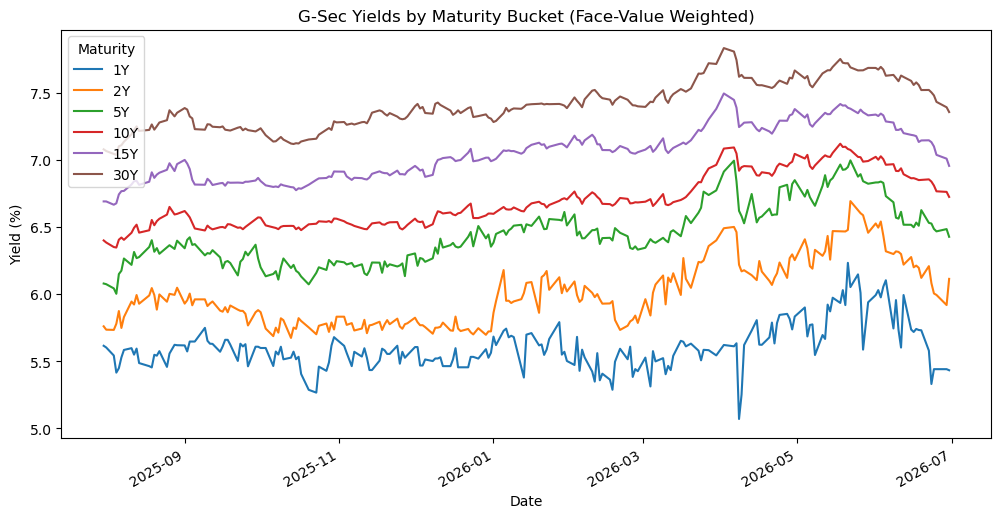

In [12]:
import matplotlib.pyplot as plt

panel.plot(figsize=(12,6))
plt.title("G-Sec Yields by Maturity Bucket (Face-Value Weighted)")
plt.ylabel("Yield (%)")
plt.xlabel("Date")
plt.legend(title="Maturity")
plt.show()

In [13]:
print("Missing values per bucket after applying min-trade threshold:")
print(panel.isna().sum())

Missing values per bucket after applying min-trade threshold:
bucket
1Y     0
2Y     0
5Y     0
10Y    0
15Y    0
30Y    0
dtype: int64


In [14]:
print(panel.index.min(), panel.index.max())
print(panel.index.to_series().diff().value_counts().head(10))

2025-07-31 00:00:00 2026-06-30 00:00:00
trade_date
1 days    156
3 days     44
2 days     11
4 days      6
Name: count, dtype: int64


In [15]:
"""
Loader for RBI DBIE "Major Monetary Policy Rates" export.
Converts the sparse rate-change table into a clean daily repo rate series,
forward-filled and aligned to your G-Sec panel's date index.
"""

'\nLoader for RBI DBIE "Major Monetary Policy Rates" export.\nConverts the sparse rate-change table into a clean daily repo rate series,\nforward-filled and aligned to your G-Sec panel\'s date index.\n'

In [16]:
import pandas as pd


In [17]:
def load_repo_rate(path, target_index=None):
    """
    path: path to the RBI DBIE xlsx export
    target_index: your daily G-Sec panel's DatetimeIndex (panel.index) --
                   if provided, the repo series is reindexed/ffilled to match it exactly
    Returns: a pandas Series named 'repo_rate', daily frequency
    """

In [18]:
raw = pd.read_excel("C:/Users/Aditi Raj/Downloads/repo rate data.xlsx", header=None)
header_row_idx = raw[raw.apply(
    lambda row: row.astype(str).str.contains('Effective Date').any(), axis=1
)].index[0]

data = raw.iloc[header_row_idx + 3:].copy()
data.columns = ['blank', 'eff_date', 'bank_rate', 'repo', 'reverse_repo',
                 'sdf', 'msf', 'crr', 'slr']
data = data.drop(columns='blank')

data['eff_date'] = pd.to_datetime(data['eff_date'], errors='coerce')
data = data.dropna(subset=['eff_date'])

data['repo'] = pd.to_numeric(data['repo'], errors='coerce')
repo_changes = data[['eff_date', 'repo']].dropna().sort_values('eff_date')
repo_changes = repo_changes.set_index('eff_date')['repo']
repo_changes = repo_changes[~repo_changes.index.duplicated(keep='last')]

C:\Users\Aditi Raj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [19]:
print(repo_changes.head(10))
print(repo_changes.tail(10))

eff_date
2001-04-27    9.00
2001-04-30    8.75
2001-06-07    8.50
2002-03-28    8.00
2002-11-12    7.50
2003-03-07    7.10
2003-03-19    7.00
2004-03-31    6.00
2005-10-26    6.25
2006-01-24    6.50
Name: repo, dtype: float64
eff_date
2022-05-04    4.40
2022-06-08    4.90
2022-08-05    5.40
2022-09-30    5.90
2022-12-07    6.25
2023-02-08    6.50
2025-02-07    6.25
2025-04-09    6.00
2025-06-06    5.50
2025-12-05    5.25
Name: repo, dtype: float64


In [20]:
target_index = panel.index

if target_index is not None:
    full_range = pd.date_range(
        start=min(repo_changes.index.min(), target_index.min()),
        end=target_index.max(),
        freq='D'
    )
    repo_daily = repo_changes.reindex(full_range).ffill()
    repo_daily = repo_daily.reindex(target_index)
else:
    repo_daily = repo_changes

repo_daily.name = 'repo_rate'
repo_daily

trade_date
2025-07-31    5.50
2025-08-01    5.50
2025-08-04    5.50
2025-08-05    5.50
2025-08-06    5.50
              ... 
2026-06-23    5.25
2026-06-24    5.25
2026-06-25    5.25
2026-06-29    5.25
2026-06-30    5.25
Name: repo_rate, Length: 218, dtype: float64

In [21]:
repo_daily.head()
repo_daily.tail()

trade_date
2026-06-23    5.25
2026-06-24    5.25
2026-06-25    5.25
2026-06-29    5.25
2026-06-30    5.25
Name: repo_rate, dtype: float64

In [22]:
repo_daily.isna().sum()

np.int64(0)

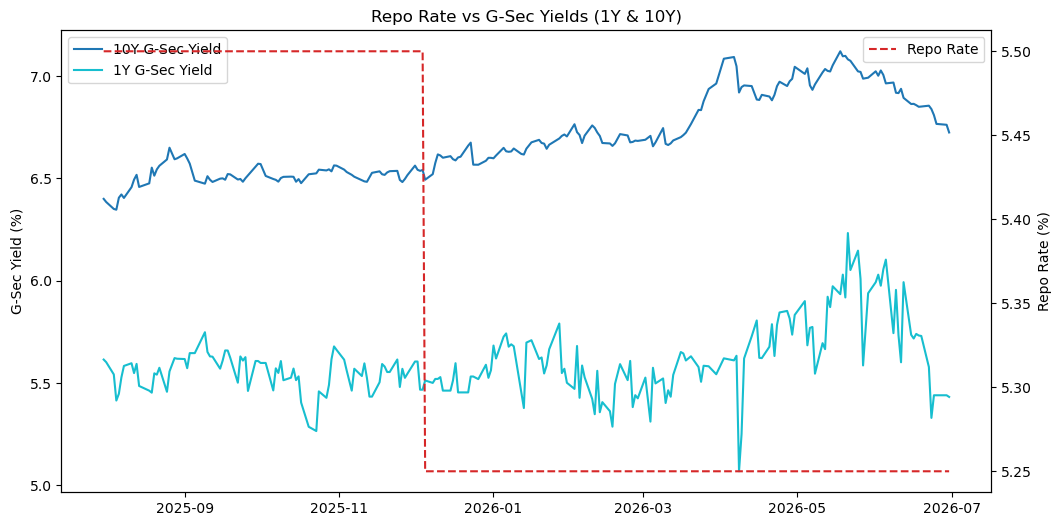

In [23]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(panel.index, panel['10Y'], label='10Y G-Sec Yield', color='tab:blue')
ax1.plot(panel.index, panel['1Y'], label='1Y G-Sec Yield', color='tab:cyan')
ax1.set_ylabel('G-Sec Yield (%)')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(repo_daily.index, repo_daily, label='Repo Rate', color='tab:red', linestyle='--')
ax2.set_ylabel('Repo Rate (%)')
ax2.legend(loc='upper right')

plt.title('Repo Rate vs G-Sec Yields (1Y & 10Y)')
plt.show()

In [24]:
"""
Loader for RBI DBIE "Monetary Survey" export -> clean M3 growth series,
aligned to your G-Sec panel's daily date index.
"""

'\nLoader for RBI DBIE "Monetary Survey" export -> clean M3 growth series,\naligned to your G-Sec panel\'s daily date index.\n'

In [25]:
import pandas as pd

In [26]:
def load_m3_growth(path, target_index=None, growth_periods=12):
    """
    path: path to the RBI DBIE Monetary Survey xlsx export
    target_index: your daily G-Sec panel's DatetimeIndex (panel.index) --
                   if provided, output is forward-filled and aligned to it
    growth_periods: 12 = YoY growth (since data is monthly), 1 = MoM growth
    Returns: a pandas Series named 'm3_growth'
    """
    raw = pd.read_excel('C:/Users/Aditi Raj/Downloads/Monetary Survey.xlsx', header=None)
 
    # data rows start after the header block; locate first row where column 1
    # parses as a real date, rather than hardcoding row 9 in case export format shifts
    date_col_parsed = pd.to_datetime(raw[1], errors='coerce')
    first_data_row = date_col_parsed.first_valid_index()
 
    data = raw.iloc[first_data_row:].copy()
    data = data[[1, 5]].copy()   # col 1 = Month/Item (date), col 5 = NM3 (M3 level)
    data.columns = ['date', 'm3']
 
    data['date'] = pd.to_datetime(data['date'], errors='coerce')
    data['m3'] = pd.to_numeric(data['m3'], errors='coerce')
    data = data.dropna(subset=['date', 'm3']).sort_values('date')
 
    m3_level = data.set_index('date')['m3']
    m3_growth = m3_level.pct_change(periods=growth_periods) * 100
    m3_growth = m3_growth.dropna()
 
    if target_index is not None:
        full_range = pd.date_range(
            start=min(m3_growth.index.min(), target_index.min()),
            end=target_index.max(),
            freq='D'
        )
        # NOTE on publication lag: RBI's Monetary Survey for a given month is
        # typically released with roughly a 3-4 week lag. Forward-filling from
        # the reported "as of" date (rather than shifting it later) is a simplification;
        # worth disclosing in your write-up as a limitation if precision matters.
        m3_daily = m3_growth.reindex(full_range).ffill()
        m3_daily = m3_daily.reindex(target_index)
    else:
        m3_daily = m3_growth
 
    m3_daily.name = 'm3_growth'
    return m3_daily
 
 
if __name__ == '__main__':
    path = '/mnt/user-data/uploads/Monetary_Survey.xlsx'
    m3_series = load_m3_growth(path)
    print(m3_series.head())
    print('...')
    print(m3_series.tail())
    print(f"\n{len(m3_series)} monthly YoY growth observations")

date
2000-04-21    2.195275e+07
2000-05-19    1.718459e+01
2000-06-30    1.696034e+01
2000-07-28    1.507340e+01
2000-08-25    1.493765e+01
Name: m3_growth, dtype: float64
...
date
2025-12-31    11.206228
2026-01-31    11.501806
2026-02-28    12.166894
2026-03-31    14.455913
2026-04-30    12.698547
Name: m3_growth, dtype: float64

313 monthly YoY growth observations


C:\Users\Aditi Raj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\Aditi Raj\AppData\Local\Temp\ipykernel_26088\728735091.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date_col_parsed = pd.to_datetime(raw[1], errors='coerce')


In [27]:
m3_series.head()
m3_series.tail()

date
2025-12-31    11.206228
2026-01-31    11.501806
2026-02-28    12.166894
2026-03-31    14.455913
2026-04-30    12.698547
Name: m3_growth, dtype: float64

In [28]:
m3_daily = load_m3_growth(
    'C:/Users/Aditi Raj/Downloads/Monetary_Survey.xlsx',
    target_index=panel.index
)
m3_daily.head()
m3_daily.tail()

C:\Users\Aditi Raj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\Aditi Raj\AppData\Local\Temp\ipykernel_26088\728735091.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date_col_parsed = pd.to_datetime(raw[1], errors='coerce')


trade_date
2026-06-23    12.698547
2026-06-24    12.698547
2026-06-25    12.698547
2026-06-29    12.698547
2026-06-30    12.698547
Name: m3_growth, dtype: float64

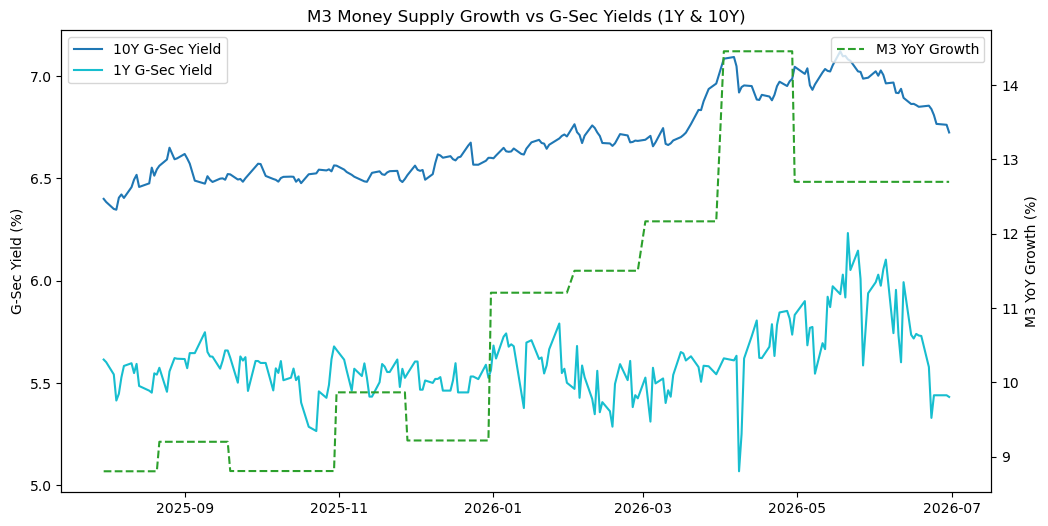

In [29]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(panel.index, panel['10Y'], label='10Y G-Sec Yield', color='tab:blue')
ax1.plot(panel.index, panel['1Y'], label='1Y G-Sec Yield', color='tab:cyan')
ax1.set_ylabel('G-Sec Yield (%)')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(m3_daily.index, m3_daily, label='M3 YoY Growth', color='tab:green', linestyle='--')
ax2.set_ylabel('M3 YoY Growth (%)')
ax2.legend(loc='upper right')

plt.title('M3 Money Supply Growth vs G-Sec Yields (1Y & 10Y)')
plt.show()

In [30]:
term_spread = panel['10Y'] - panel['1Y']
term_spread.name = 'term_spread'
term_spread.head()
term_spread.tail()

trade_date
2026-06-23    1.508865
2026-06-24    1.368789
2026-06-25    1.325823
2026-06-29    1.321556
2026-06-30    1.292072
Name: term_spread, dtype: float64

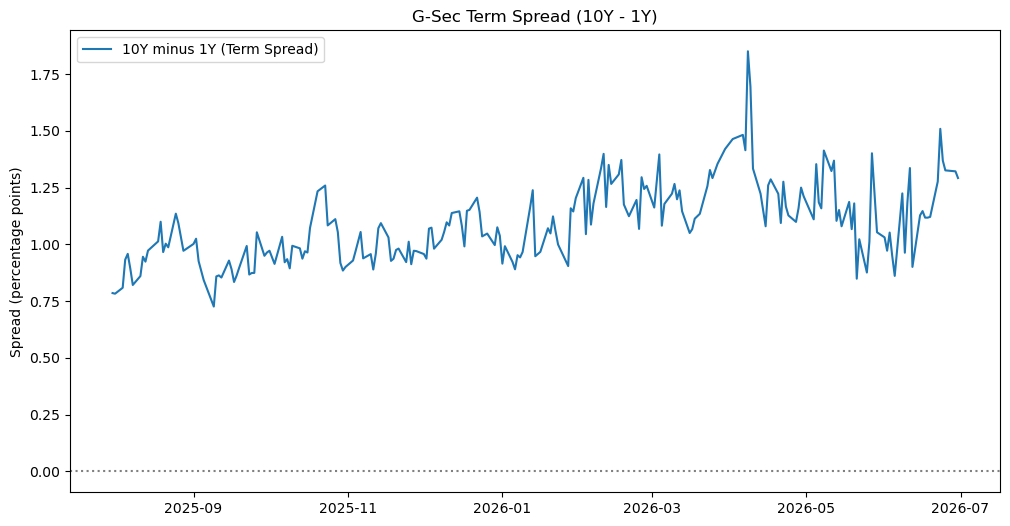

In [31]:
plt.figure(figsize=(12,6))
plt.plot(term_spread.index, term_spread, label='10Y minus 1Y (Term Spread)')
plt.axhline(0, color='gray', linestyle=':')
plt.title('G-Sec Term Spread (10Y - 1Y)')
plt.ylabel('Spread (percentage points)')
plt.legend()
plt.show()

In [32]:
import pandas as pd

def load_us10y(path, target_index=None):
    raw = pd.read_excel('C:/Users/Aditi Raj/Downloads/fred data.xlsx', sheet_name='Daily')
    raw.columns = ['date', 'us_10y']

    raw['date'] = pd.to_datetime(raw['date'], errors='coerce')
    raw['us_10y'] = pd.to_numeric(raw['us_10y'], errors='coerce')
    raw = raw.dropna(subset=['date']).sort_values('date').set_index('date')['us_10y']

    if target_index is not None:
        full_range = pd.date_range(
            start=min(raw.index.min(), target_index.min()),
            end=target_index.max(),
            freq='D'
        )
        us10y_daily = raw.reindex(full_range).ffill()
        us10y_daily = us10y_daily.reindex(target_index)
    else:
        us10y_daily = raw

    us10y_daily.name = 'us_10y'
    return us10y_daily

In [33]:
us10y_daily = load_us10y(
    'C:/Users/Aditi Raj/Downloads/fred data.xlsx',
    target_index=panel.index
)
us10y_daily.head()
us10y_daily.tail()

trade_date
2026-06-23    4.50
2026-06-24    4.41
2026-06-25    4.40
2026-06-29    4.38
2026-06-30    4.44
Name: us_10y, dtype: float64

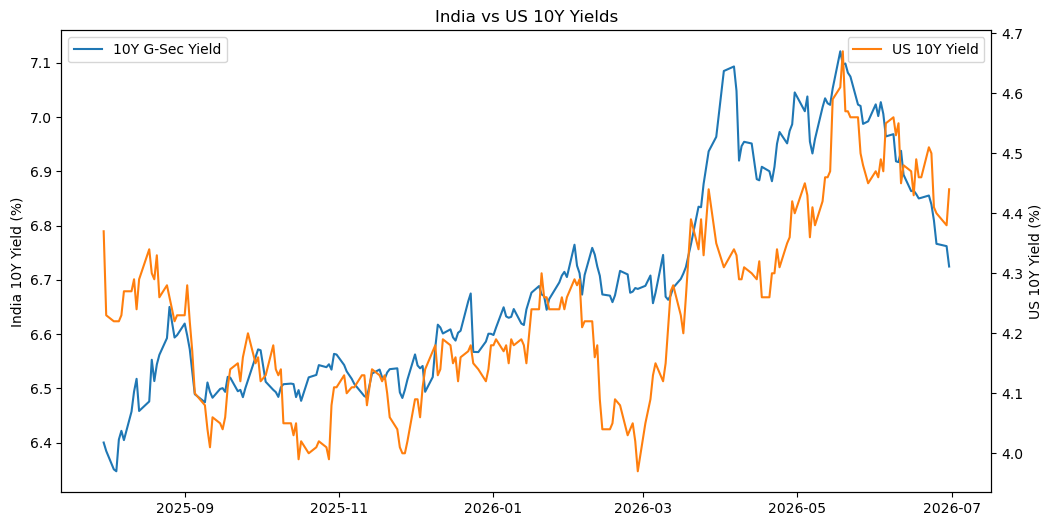

In [34]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))
ax1.plot(panel.index, panel['10Y'], label='10Y G-Sec Yield', color='tab:blue')
ax1.set_ylabel('India 10Y Yield (%)')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(us10y_daily.index, us10y_daily, label='US 10Y Yield', color='tab:orange')
ax2.set_ylabel('US 10Y Yield (%)')
ax2.legend(loc='upper right')

plt.title('India vs US 10Y Yields')
plt.show()

In [35]:
"""
Loader for RBI DBIE "Exchange Rate of the Indian Rupee..." export.
Extracts the US Dollar End-month spot rate and forward-fills to daily,
aligned to your G-Sec panel's date index.
"""

'\nLoader for RBI DBIE "Exchange Rate of the Indian Rupee..." export.\nExtracts the US Dollar End-month spot rate and forward-fills to daily,\naligned to your G-Sec panel\'s date index.\n'

In [36]:
import pandas as pd

def load_usdinr(path, target_index=None):
    raw = pd.read_excel('C:/Users/Aditi Raj/Downloads/USD INR spot rates.xlsx', header=None)

    date_col_parsed = pd.to_datetime(raw[1], errors='coerce')
    first_data_row = date_col_parsed.first_valid_index()

    data = raw.iloc[first_data_row:].copy()
    data = data[[1, 6]].copy()
    data.columns = ['date', 'usdinr']

    data['date'] = pd.to_datetime(data['date'], errors='coerce')
    data['usdinr'] = pd.to_numeric(data['usdinr'], errors='coerce')
    data = data.dropna(subset=['date', 'usdinr']).sort_values('date')

    usdinr_level = data.set_index('date')['usdinr']

    if target_index is not None:
        full_range = pd.date_range(
            start=min(usdinr_level.index.min(), target_index.min()),
            end=target_index.max(),
            freq='D'
        )
        usdinr_daily = usdinr_level.reindex(full_range).ffill()
        usdinr_daily = usdinr_daily.reindex(target_index)
    else:
        usdinr_daily = usdinr_level

    usdinr_daily.name = 'usdinr'
    return usdinr_daily

In [37]:
usdinr_daily = load_usdinr(
    'C:/Users/Aditi Raj/Downloads/USD_INR_spot_rates.xlsx',
    target_index=panel.index
)
usdinr_daily.head()
usdinr_daily.tail()

C:\Users\Aditi Raj\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
C:\Users\Aditi Raj\AppData\Local\Temp\ipykernel_26088\3581318506.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date_col_parsed = pd.to_datetime(raw[1], errors='coerce')


trade_date
2026-06-23    95.3845
2026-06-24    95.3845
2026-06-25    95.3845
2026-06-29    95.3845
2026-06-30    94.5975
Name: usdinr, dtype: float64

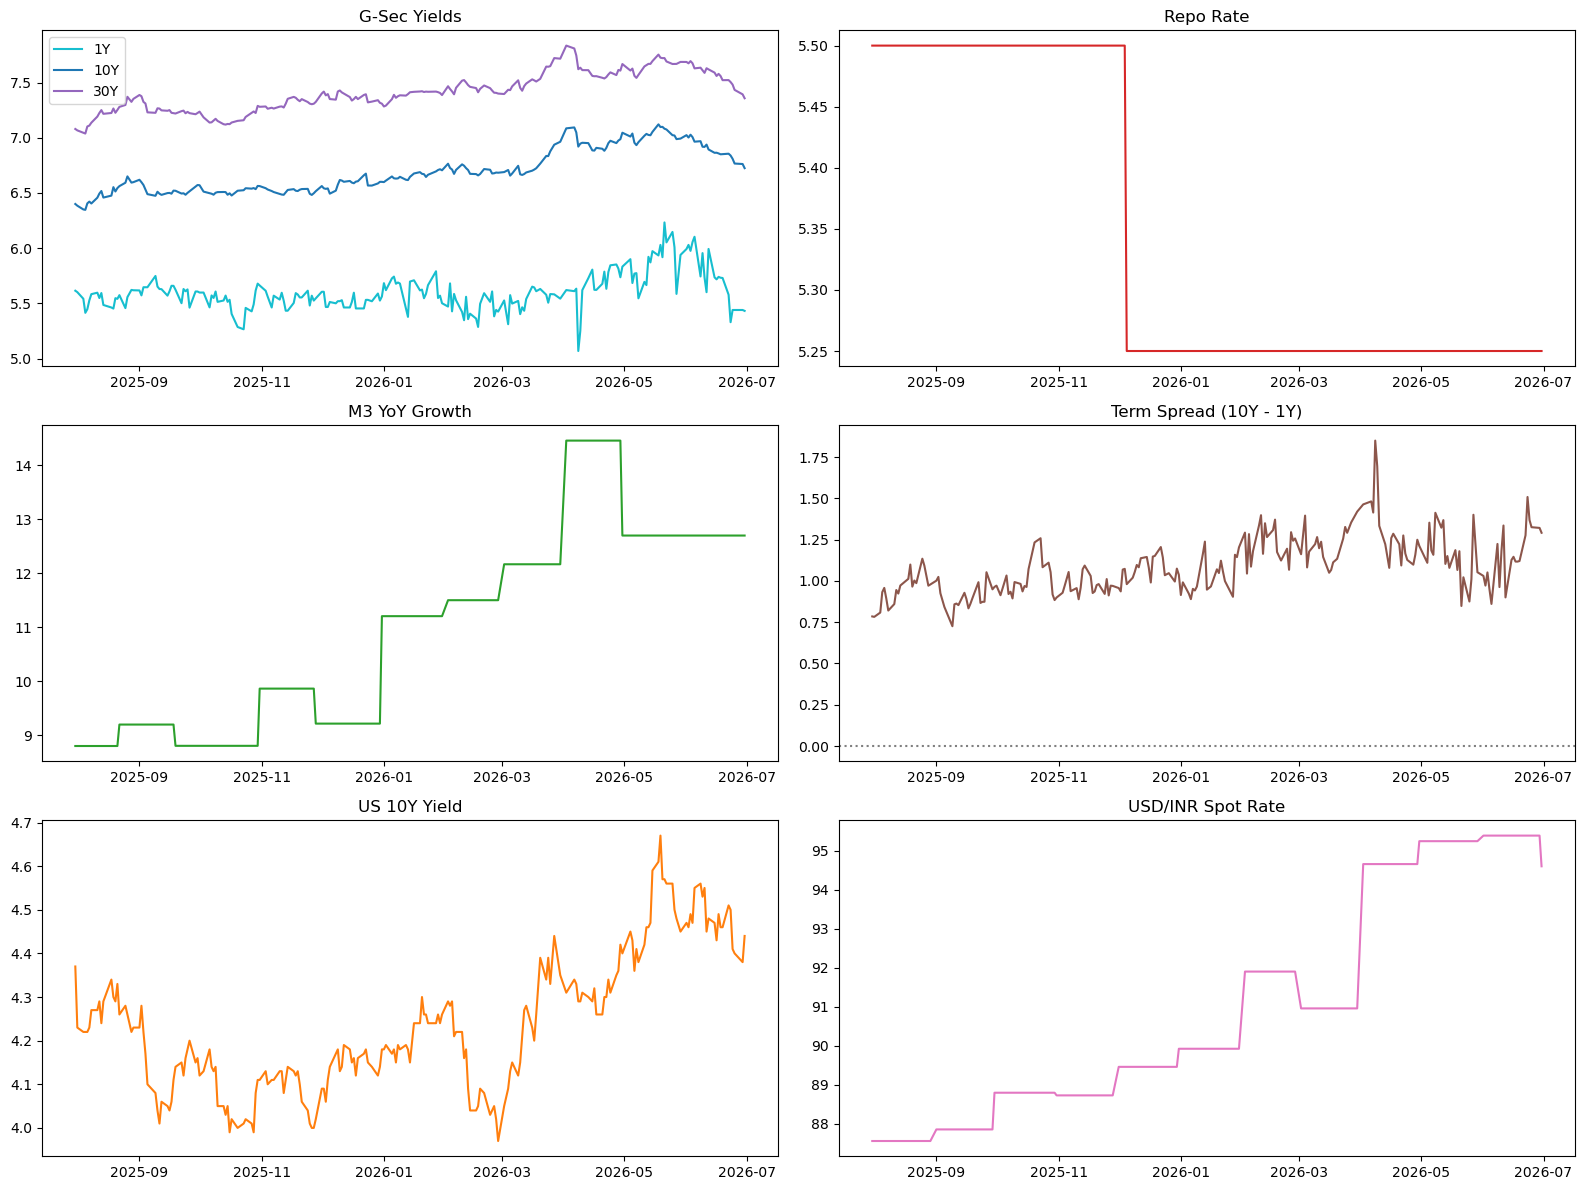

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

axes[0,0].plot(panel.index, panel['1Y'], label='1Y', color='tab:cyan')
axes[0,0].plot(panel.index, panel['10Y'], label='10Y', color='tab:blue')
axes[0,0].plot(panel.index, panel['30Y'], label='30Y', color='tab:purple')
axes[0,0].set_title('G-Sec Yields')
axes[0,0].legend()

axes[0,1].plot(repo_daily.index, repo_daily, color='tab:red')
axes[0,1].set_title('Repo Rate')

axes[1,0].plot(m3_daily.index, m3_daily, color='tab:green')
axes[1,0].set_title('M3 YoY Growth')

axes[1,1].plot(term_spread.index, term_spread, color='tab:brown')
axes[1,1].axhline(0, color='gray', linestyle=':')
axes[1,1].set_title('Term Spread (10Y - 1Y)')

axes[2,0].plot(us10y_daily.index, us10y_daily, color='tab:orange')
axes[2,0].set_title('US 10Y Yield')

axes[2,1].plot(usdinr_daily.index, usdinr_daily, color='tab:pink')
axes[2,1].set_title('USD/INR Spot Rate')

plt.tight_layout()
plt.show()

In [39]:
forward_premium_proxy = repo_daily - us10y_daily
forward_premium_proxy.name = 'forward_premium_proxy'
forward_premium_proxy.head()
forward_premium_proxy.tail()

trade_date
2026-06-23    0.75
2026-06-24    0.84
2026-06-25    0.85
2026-06-29    0.87
2026-06-30    0.81
Name: forward_premium_proxy, dtype: float64

In [40]:
final_matrix = panel.join([repo_daily, m3_daily, term_spread, us10y_daily, usdinr_daily, forward_premium_proxy])
final_matrix.head()
final_matrix.tail()

,1Y,2Y,5Y,10Y,15Y,30Y,repo_rate,m3_growth,term_spread,us_10y,usdinr,forward_premium_proxy
trade_date,,,,,,,,,,,,
2026-06-23,5.330147,6.081806,6.526352,6.839012,7.132878,7.504108,5.25,12.698547,1.508865,4.50,95.3845,0.75
2026-06-24,5.440653,6.004909,6.485993,6.809441,7.101055,7.481178,5.25,12.698547,1.368789,4.41,95.3845,0.84
2026-06-25,5.440653,5.993999,6.467841,6.766475,7.038071,7.433214,5.25,12.698547,1.325823,4.40,95.3845,0.85
2026-06-29,5.440653,5.918608,6.484850,6.762209,7.009835,7.392915,5.25,12.698547,1.321556,4.38,95.3845,0.87
2026-06-30,5.432574,6.113743,6.427443,6.724646,6.955980,7.357370,5.25,12.698547,1.292072,4.44,94.5975,0.81


In [41]:
final_matrix.isna().sum()

1Y                       0
2Y                       0
5Y                       0
10Y                      0
15Y                      0
30Y                      0
repo_rate                0
m3_growth                0
term_spread              0
us_10y                   0
usdinr                   0
forward_premium_proxy    0
dtype: int64

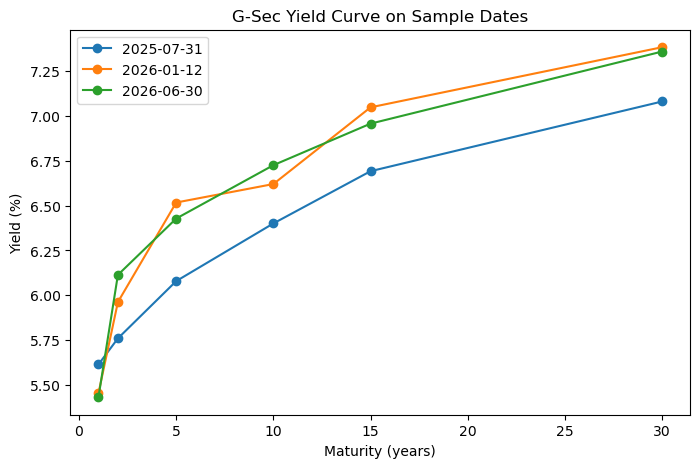

In [42]:
import matplotlib.pyplot as plt

sample_dates = [panel.index[0], panel.index[len(panel)//2], panel.index[-1]]
maturities = [1, 2, 5, 10, 15, 30]

plt.figure(figsize=(8,5))
for date in sample_dates:
    plt.plot(maturities, panel.loc[date, ['1Y','2Y','5Y','10Y','15Y','30Y']], marker='o', label=str(date.date()))

plt.xlabel('Maturity (years)')
plt.ylabel('Yield (%)')
plt.title('G-Sec Yield Curve on Sample Dates')
plt.legend()
plt.show()

---

# Week 2 — PCA Decomposition (Dua & Raje Variable Set)

**Goal:** assemble the final input matrix (G-Sec yields across maturities + repo rate + M3 growth
+ term spread + US 10Y + forward premium proxy), align to weekly frequency, center the data,
run PCA, and interpret PC1/PC2/PC3.

**Carried over from Week 1:** `panel`, `repo_daily`, `m3_daily`, `term_spread`, `us10y_daily`,
`usdinr_daily`, `forward_premium_proxy`, `final_matrix` — all built and verified with zero
missing values.

---

In [44]:
weekly_matrix = final_matrix.resample('W-FRI').last()
weekly_matrix.head()
weekly_matrix.tail()
weekly_matrix.isna().sum()

1Y                       0
2Y                       0
5Y                       0
10Y                      0
15Y                      0
30Y                      0
repo_rate                0
m3_growth                0
term_spread              0
us_10y                   0
usdinr                   0
forward_premium_proxy    0
dtype: int64

In [49]:
weekly_standardized = (weekly_matrix - weekly_matrix.mean()) / weekly_matrix.std()
weekly_standardized.head()

,1Y,2Y,5Y,10Y,15Y,30Y,repo_rate,m3_growth,term_spread,us_10y,usdinr,forward_premium_proxy
trade_date,,,,,,,,,,,,
2025-08-01,-0.065914,-1.130468,-1.697560,-1.539366,-1.791146,-1.903089,1.298874,-1.180143,-1.810702,-0.049452,-1.190493,0.685502
2025-08-08,-0.175368,-0.741057,-0.829762,-1.438503,-1.392608,-1.515461,1.298874,-1.180143,-1.573754,0.205616,-1.190493,0.520239
2025-08-15,-0.756158,-0.327811,-0.780518,-1.167138,-1.162206,-1.066384,1.298874,-1.180143,-0.638549,0.333150,-1.190493,0.437608
2025-08-22,-0.228509,-0.040103,-0.670655,-0.643954,-0.704438,-0.716358,1.298874,-0.963082,-0.548520,0.141849,-1.190493,0.561555
2025-08-29,0.034069,0.166963,-0.227414,-0.460600,-0.377820,-0.311124,1.298874,-0.963082,-0.597721,-0.049452,-1.190493,0.685502


In [50]:
weekly_standardized.mean()
weekly_standardized.std()

1Y                       1.0
2Y                       1.0
5Y                       1.0
10Y                      1.0
15Y                      1.0
30Y                      1.0
repo_rate                1.0
m3_growth                1.0
term_spread              1.0
us_10y                   1.0
usdinr                   1.0
forward_premium_proxy    1.0
dtype: float64

In [51]:
corr_based_cov = weekly_standardized.cov()
corr_based_cov

,1Y,2Y,5Y,10Y,15Y,30Y,repo_rate,m3_growth,term_spread,us_10y,usdinr,forward_premium_proxy
1Y,1.000000,0.682025,0.664707,0.619017,0.573273,0.555453,-0.271607,0.448932,-0.284147,0.669888,0.525378,-0.570675
2Y,0.682025,1.000000,0.896957,0.884672,0.847980,0.836457,-0.533416,0.769393,0.370803,0.812447,0.750808,-0.794757
5Y,0.664707,0.896957,1.000000,0.929909,0.936858,0.903139,-0.700198,0.799345,0.444036,0.744503,0.792338,-0.834643
10Y,0.619017,0.884672,0.929909,1.000000,0.971287,0.950248,-0.713956,0.900684,0.577113,0.742922,0.913244,-0.840540
15Y,0.573273,0.847980,0.936858,0.971287,1.000000,0.972741,-0.779248,0.883280,0.589627,0.667207,0.846740,-0.824331
30Y,0.555453,0.836457,0.903139,0.950248,0.972741,1.000000,-0.748163,0.869979,0.582473,0.674755,0.835405,-0.813583
repo_rate,-0.271607,-0.533416,-0.700198,-0.713956,-0.779248,-0.748163,1.000000,-0.761921,-0.589164,-0.501739,-0.738084,0.828182
m3_growth,0.448932,0.769393,0.799345,0.900684,0.883280,0.869979,-0.761921,1.000000,0.632730,0.628098,0.903553,-0.790275
term_spread,-0.284147,0.370803,0.444036,0.577113,0.589627,0.582473,-0.589164,0.632730,1.000000,0.210378,0.568572,-0.432714
us_10y,0.669888,0.812447,0.744503,0.742922,0.667207,0.674755,-0.501739,0.628098,0.210378,1.000000,0.702167,-0.900339


In [52]:
import numpy as np

eigenvalues, eigenvectors = np.linalg.eig(corr_based_cov)

# sort by eigenvalue, descending (largest = most variance explained)
sort_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

print("Eigenvalues:", eigenvalues)
print("\nVariance explained by each component:")
variance_explained = eigenvalues / eigenvalues.sum() * 100
for i, v in enumerate(variance_explained[:5]):
    print(f"PC{i+1}: {v:.2f}%")

Eigenvalues: [ 8.97605404e+00  1.55120835e+00  5.02314750e-01  4.04171004e-01
  2.77052725e-01  1.12690607e-01  8.76543408e-02  5.28588315e-02
  2.91167283e-02  6.87862532e-03  5.64324479e-16 -9.23212114e-17]

Variance explained by each component:
PC1: 74.80%
PC2: 12.93%
PC3: 4.19%
PC4: 3.37%
PC5: 2.31%


In [53]:
import pandas as pd

loadings = pd.DataFrame(
    eigenvectors[:, :4],
    index=weekly_matrix.columns,
    columns=['PC1', 'PC2', 'PC3', 'PC4']
)
loadings

,PC1,PC2,PC3,PC4
1Y,0.206768,-0.600364,0.146888,0.300603
2Y,0.299329,-0.180985,0.229395,-0.362648
5Y,0.314490,-0.087393,0.177322,0.039786
10Y,0.326880,0.012743,0.222622,-0.024801
15Y,0.322133,0.061791,0.230317,0.167525
30Y,0.317331,0.060716,0.230872,0.110074
repo_rate,-0.265029,-0.258528,0.492784,-0.550576
m3_growth,0.305378,0.155378,0.090476,0.091630
term_spread,0.184047,0.639836,0.119035,-0.342855
us_10y,0.268628,-0.286973,-0.435852,-0.546732


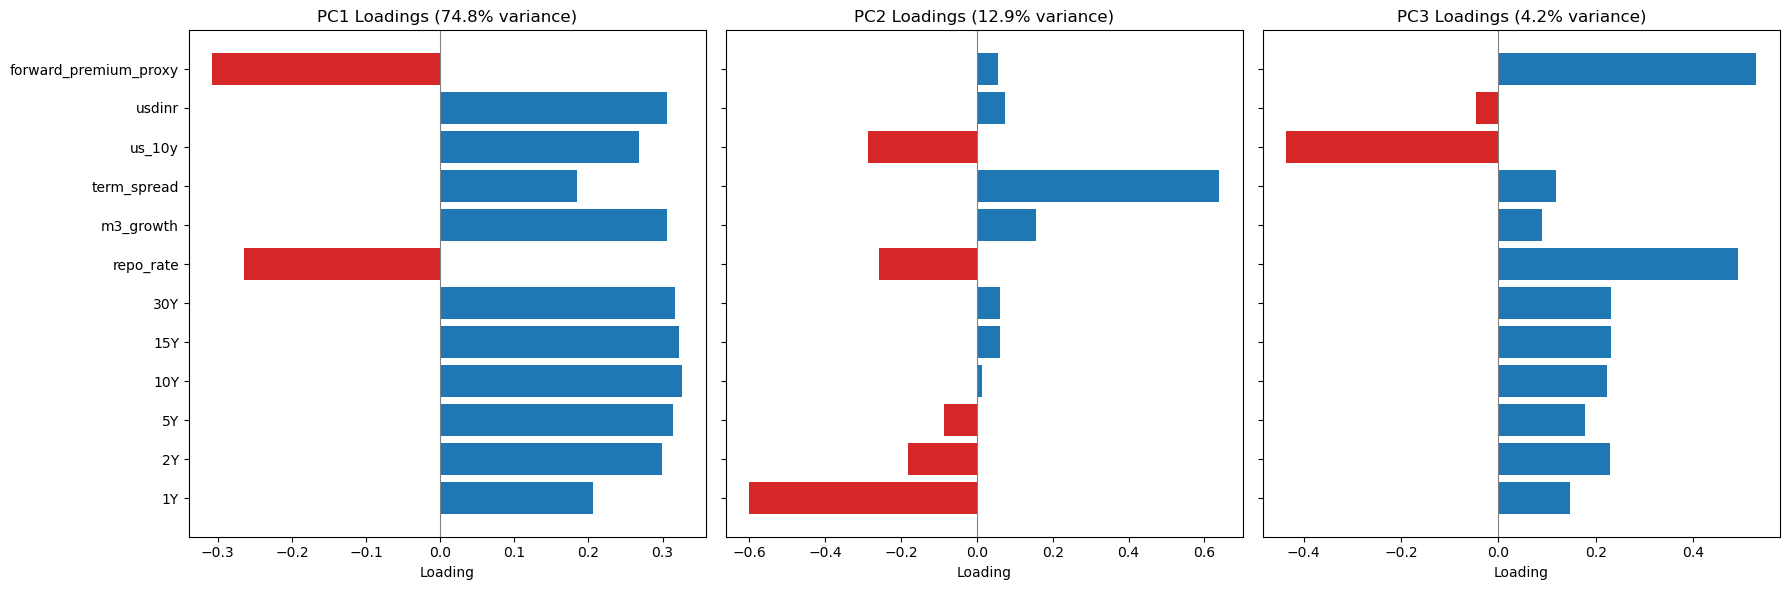

In [54]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, pc in enumerate(['PC1', 'PC2', 'PC3']):
    colors = ['tab:blue' if v >= 0 else 'tab:red' for v in loadings[pc]]
    axes[i].barh(loadings.index, loadings[pc], color=colors)
    axes[i].axvline(0, color='gray', linewidth=0.8)
    axes[i].set_title(f'{pc} Loadings ({variance_explained[i]:.1f}% variance)')
    axes[i].set_xlabel('Loading')

plt.tight_layout()
plt.show()

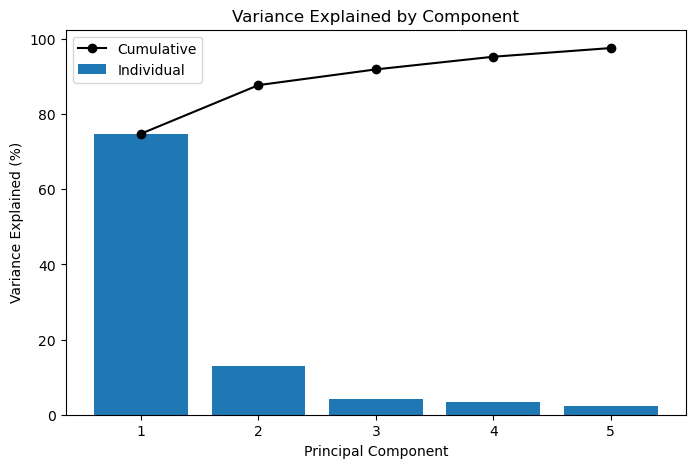

In [55]:
plt.figure(figsize=(8,5))
cum_var = variance_explained.cumsum()
plt.bar(range(1, 6), variance_explained[:5], label='Individual')
plt.plot(range(1, 6), cum_var[:5], color='black', marker='o', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('Variance Explained by Component')
plt.legend()
plt.show()